# AlphaZero-lite: a small ResNet, a tree, and a budget

Self-play with no external data. Every move is chosen by a tree search *guided*
by the network — and a search of a few hundred simulations plays better than
the network's raw opinion. Then the network is trained to predict what that
search decided. The network chases its own search; the search, built on a
better network, pulls further ahead.

This notebook is about two things the build got wrong first and then right: the
move encoding, and the budget.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## The move encoding is 96% of the design

The obvious choice is one policy output per `from × to` pair — 4,096 of them,
simple to write. Producing that needs a dense layer from the tower's flattened
features. AlphaZero's 8×8×73 scheme is produced by a 1×1 convolution instead.

In [2]:
from research.alphazero_lite.encoding import MOVE_PLANES, POLICY_SIZE
from research.alphazero_lite.network import NetworkConfig, build_network, parameter_count

tower = NetworkConfig()
model = build_network(tower)
actual = parameter_count(model)

# What a dense from-to head would have cost instead.
flat_head = 32 * 64 * 4096 + 4096
plane_head = tower.channels * MOVE_PLANES + MOVE_PLANES
hypothetical = actual - plane_head + flat_head

print(f"tower:                 {tower.describe()}")
print(f"policy planes:         {MOVE_PLANES} -> {POLICY_SIZE:,} outputs")
print(f"policy head (1x1 conv) {plane_head:>10,} parameters")
print(f"policy head (dense)    {flat_head:>10,} parameters")
print()
print(f"whole network, planes: {actual:>10,}")
print(f"whole network, dense:  {hypothetical:>10,}   ({flat_head / hypothetical:.0%} of it the output layer)")

tower:                 4 blocks x 64 channels
policy planes:         73 -> 4,672 outputs
policy head (1x1 conv)      4,745 parameters
policy head (dense)     8,392,704 parameters

whole network, planes:    345,178
whole network, dense:   8,733,137   (96% of it the output layer)


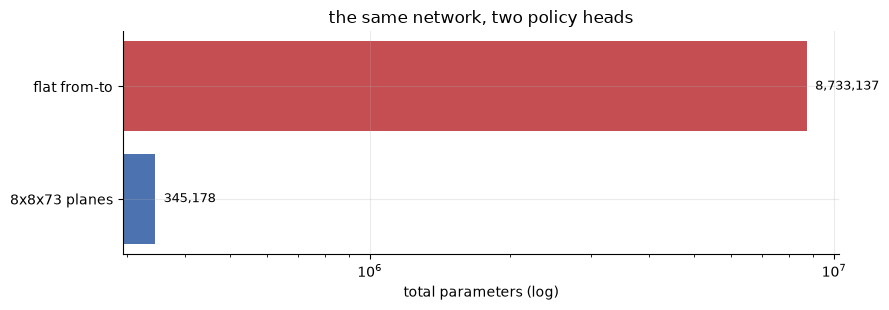

In [3]:
fig, axis = plt.subplots(figsize=(9, 3.2))
axis.barh(["8x8x73 planes", "flat from-to"], [actual, hypothetical], color=["#4c72b0", "#c44e52"])
axis.set_xscale("log"); axis.set_xlabel("total parameters (log)")
for y, value in enumerate([actual, hypothetical]):
    axis.annotate(f"{value:,}", (value, y), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
axis.set_title("the same network, two policy heads")
plt.tight_layout(); plt.show()

The plane scheme also encodes underpromotion, which the flat one has to
pretend away.

In [4]:
import chess
from research.alphazero_lite.encoding import index_to_move, move_index, move_plane

board = chess.Board("r3k2r/pPppqpb1/bn2pnp1/3PN3/1p2P3/2N2Q1p/PPPBBPPP/R3K2R w KQkq - 0 1")
promotions = [m for m in board.legal_moves if m.promotion]
for move in promotions[:6]:
    kind = "queen" if move.promotion == chess.QUEEN else chess.piece_name(move.promotion)
    print(f"{move.uci():<6} -> plane {move_plane(move, False):>2}  ({kind})")

collisions = {}
for move in board.legal_moves:
    index = move_index(move, False)
    assert index not in collisions and index_to_move(index, board) == move
    collisions[index] = move
print(f"\nall {len(collisions)} legal moves encode uniquely and decode back")

b7a8q  -> plane 49  (queen)
b7a8r  -> plane 70  (rook)
b7a8b  -> plane 67  (bishop)
b7a8n  -> plane 64  (knight)
b7b8q  -> plane  0  (queen)
b7b8r  -> plane 71  (rook)

all 56 legal moves encode uniquely and decode back


## The tree, checked without the network

With a uniform evaluator — flat priors, every position scored as a draw — the
network contributes nothing at all. A move found here was found by search, and
a sign error anywhere in the backup would make it pick something else.

chosen: Qe8#   root value +0.943
terminal positions hit: 377, max depth 1


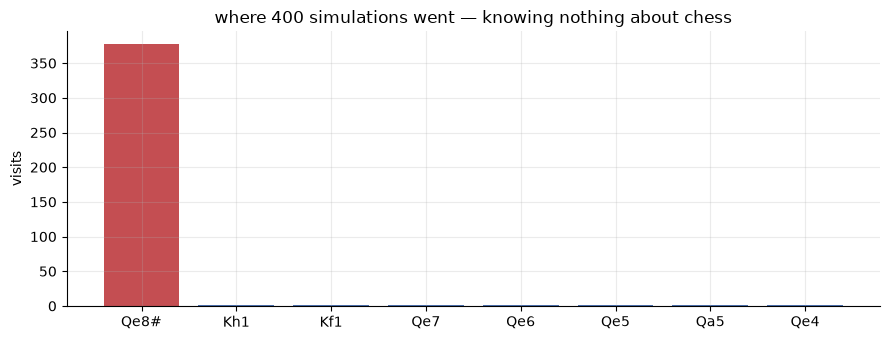

In [5]:
from research.alphazero_lite.mcts import MCTS, MCTSConfig
from research.alphazero_lite.network import UniformEvaluator

board = chess.Board("6k1/5ppp/8/8/8/8/5PPP/4Q1K1 w - - 0 1")
mcts = MCTS(UniformEvaluator(), MCTSConfig(simulations=400, dirichlet_weight=0.0), seed=1)
root, visits = mcts.search(board)
chosen = mcts.select_move(visits, ply=99)

print(f"chosen: {board.san(chosen)}   root value {root.value:+.3f}")
print(f"terminal positions hit: {mcts.stats.terminal_hits}, max depth {mcts.stats.max_depth_reached}")

top = sorted(visits.items(), key=lambda kv: -kv[1])[:8]
fig, axis = plt.subplots(figsize=(9, 3.5))
axis.bar([board.san(m) for m, _ in top], [n for _, n in top],
         color=["#c44e52" if m == chosen else "#4c72b0" for m, _ in top])
axis.set_ylabel("visits"); axis.set_title("where 400 simulations went — knowing nothing about chess")
plt.tight_layout(); plt.show()

## How the tree spends its simulations

Early on the prior dominates and the search follows the network; as visits
accumulate the tree's own numbers take over. That crossover is the algorithm.

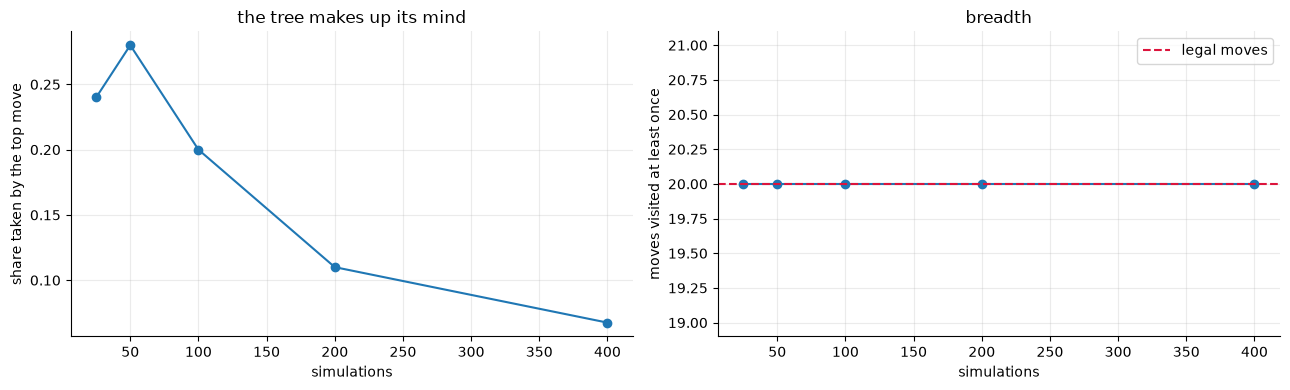

In [6]:
from research.alphazero_lite.network import Evaluator

evaluator = Evaluator(model)
start = chess.Board()
spread = []
for count in (25, 50, 100, 200, 400):
    search = MCTS(evaluator, MCTSConfig(simulations=count), seed=3)
    _, counts = search.search(start)
    ordered = sorted(counts.values(), reverse=True)
    spread.append((count, ordered[0] / count, len([c for c in ordered if c > 0])))

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.plot([s[0] for s in spread], [s[1] for s in spread], marker="o")
left.set_xlabel("simulations"); left.set_ylabel("share taken by the top move")
left.set_title("the tree makes up its mind")
right.plot([s[0] for s in spread], [s[2] for s in spread], marker="o")
right.axhline(start.legal_moves.count(), color="crimson", ls="--", label="legal moves")
right.set_xlabel("simulations"); right.set_ylabel("moves visited at least once")
right.set_title("breadth"); right.legend()
plt.tight_layout(); plt.show()

## A training iteration end to end

In [7]:
from research.alphazero_lite.selfplay import AlphaZeroLite, SelfPlayConfig, TrainConfig

trainer = AlphaZeroLite(
    network=build_network(NetworkConfig(blocks=2, channels=32)),
    mcts_config=MCTSConfig(simulations=32, temperature_plies=8),
    selfplay_config=SelfPlayConfig(games=4, max_plies=50, seed=1),
    train_config=TrainConfig(iterations=4, epochs=4, batch_size=32),
)
report = trainer.run(on_iteration=lambda r: print(
    f"iter {r.iteration}: {r.examples:>4} examples  policy {r.policy_loss:.3f}  "
    f"value {r.value_loss:.4f}  {r.seconds:.0f}s"))
print()
print(report.table())

iter 1:  185 examples  policy 5.374  value 0.0208  6s


iter 2:  200 examples  policy 4.899  value 0.0305  7s


iter 3:  200 examples  policy 3.304  value 0.0002  7s


iter 4:  187 examples  policy 3.155  value 0.0000  7s

 iter  games  examples    policy    value  decisive     time
------------------------------------------------------------
    1      4       185    5.3740   0.0208      25%     6.1s
    2      4       200    4.8985   0.0305       0%     6.7s
    3      4       200    3.3036   0.0002       0%     6.9s
    4      4       187    3.1546   0.0000       0%     7.0s


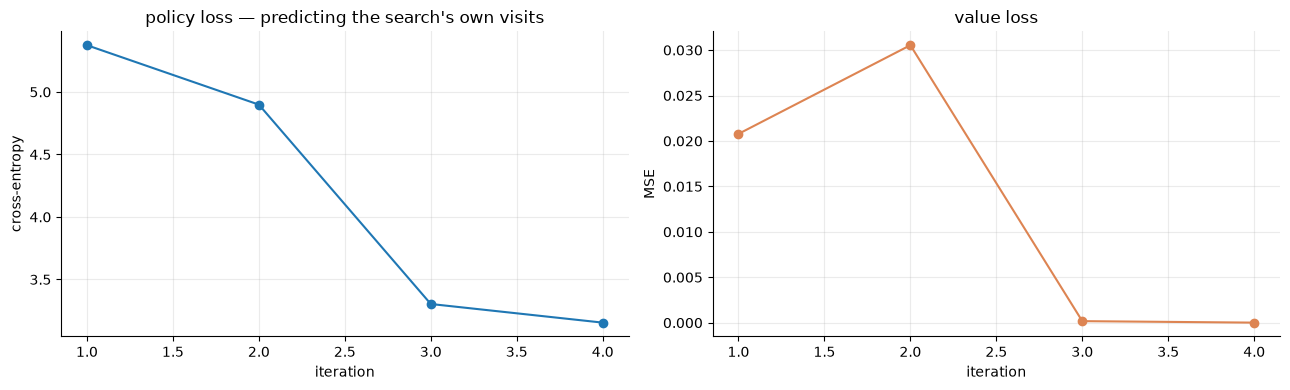

In [8]:
iterations = [r.iteration for r in report.iterations]
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.plot(iterations, [r.policy_loss for r in report.iterations], marker="o")
left.set_xlabel("iteration"); left.set_ylabel("cross-entropy")
left.set_title("policy loss — predicting the search's own visits")
right.plot(iterations, [r.value_loss for r in report.iterations], marker="o", color="#dd8452")
right.set_xlabel("iteration"); right.set_ylabel("MSE")
right.set_title("value loss")
plt.tight_layout(); plt.show()

**Read the value loss with suspicion here.** Games this short almost all end at
the move limit, so nearly every value target is 0 and the network learns to
predict 0 — which is trivially correct and teaches nothing. It is an artifact of
the demo size, not a result.

## The budget

This is the number that shapes every other decision in the module.

In [9]:
import time
from research.alphazero_lite.encoding import encode_board

planes = encode_board(chess.Board())
batch = np.stack([planes] * 64)

for _ in range(5):
    evaluator.evaluate(planes)
started = time.perf_counter()
for _ in range(50):
    evaluator.evaluate(planes)
single_ms = (time.perf_counter() - started) / 50 * 1000

started = time.perf_counter()
for _ in range(10):
    evaluator.evaluate_batch(batch)
batch_ms = (time.perf_counter() - started) / (10 * 64) * 1000

timed = MCTS(evaluator, MCTSConfig(simulations=100), seed=1)
started = time.perf_counter(); timed.search(chess.Board())
per_sim_ms = (time.perf_counter() - started) / 100 * 1000

move_s = per_sim_ms * 400 / 1000
game_s = move_s * 80
print(f"forward pass, one position     {single_ms:8.2f} ms")
print(f"forward pass, batched over 64  {batch_ms:8.3f} ms   ({single_ms / batch_ms:.0f}x cheaper)")
print(f"MCTS, per simulation           {per_sim_ms:8.2f} ms")
print(f"400 simulations (one move)     {move_s:8.2f} s")
print(f"one 80-move self-play game     {game_s:8.0f} s")
print()
print(f"one core, one hour:   {3600 / game_s:>8,.0f} games")
print(f"ten cores, one day:   {10 * 86400 / game_s:>8,.0f} games")
print(f"AlphaZero used:       {40_000_000:>8,} games")

forward pass, one position         1.02 ms
forward pass, batched over 64     0.327 ms   (3x cheaper)
MCTS, per simulation               1.24 ms
400 simulations (one move)         0.49 s
one 80-move self-play game           40 s

one core, one hour:         91 games
ten cores, one day:     21,848 games
AlphaZero used:       40,000,000 games


## What follows from the budget

Two things, and both are already in the code.

**The network is sized so a few thousand games can fill it** rather than be
memorised by it. 345K parameters is about a fiftieth of AlphaZero's twenty
blocks at 256 channels — not an apology, a consequence.

**The evaluator exposes a batch interface** because the ratio above is sitting
there for whoever implements virtual-loss parallel MCTS. That is the single
largest speedup available in this module, and it is a scheduling change rather
than a modelling one.